In [1]:
import cv2
import glob 
import math
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
refFilename = "data/images/original.png"
refFilename2 = "data/images/scanned.png"

In [3]:
im1 = cv2.imread(refFilename,cv2.IMREAD_COLOR)
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)

im2 = cv2.imread(refFilename2,cv2.IMREAD_COLOR)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

In [4]:
im1_gray = cv2.cvtColor(im1, cv2.COLOR_RGB2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY)

In [5]:
MAX_NUM_FEATURE = 500
orb = cv2.ORB_create(MAX_NUM_FEATURE)
keypoints1, descriptors1 = orb.detectAndCompute(im1_gray,None)
keypoints2, descriptors2 = orb.detectAndCompute(im2_gray,None)

im1_display = cv2.drawKeypoints(im1, keypoints1, outImage = np.array([]), color=(255,0,0), flags = cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS )
im2_display = cv2.drawKeypoints(im2, keypoints2, outImage = np.array([]), color=(255,0,0), flags = cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS )

Text(0.5, 1.0, 'Scanned Form')

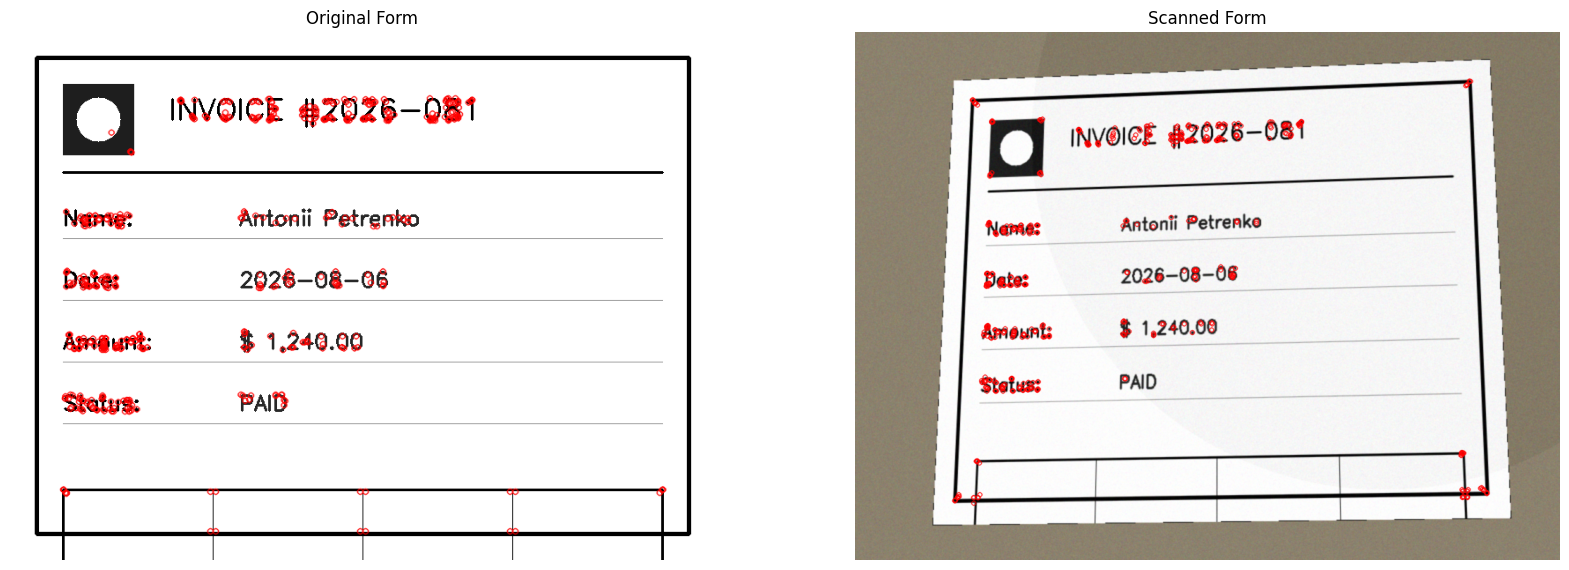

In [6]:
plt.figure(figsize=[20,10])
plt.subplot(121); plt.axis('off'); plt.imshow(im1_display); plt.title("Original Form")
plt.subplot(122); plt.axis('off'); plt.imshow(im2_display); plt.title("Scanned Form")

In [7]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descriptors1, descriptors2, None)

matches = sorted(matches, key=lambda x: x.distance)
numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]

Text(0.5, 1.0, 'Original Form')

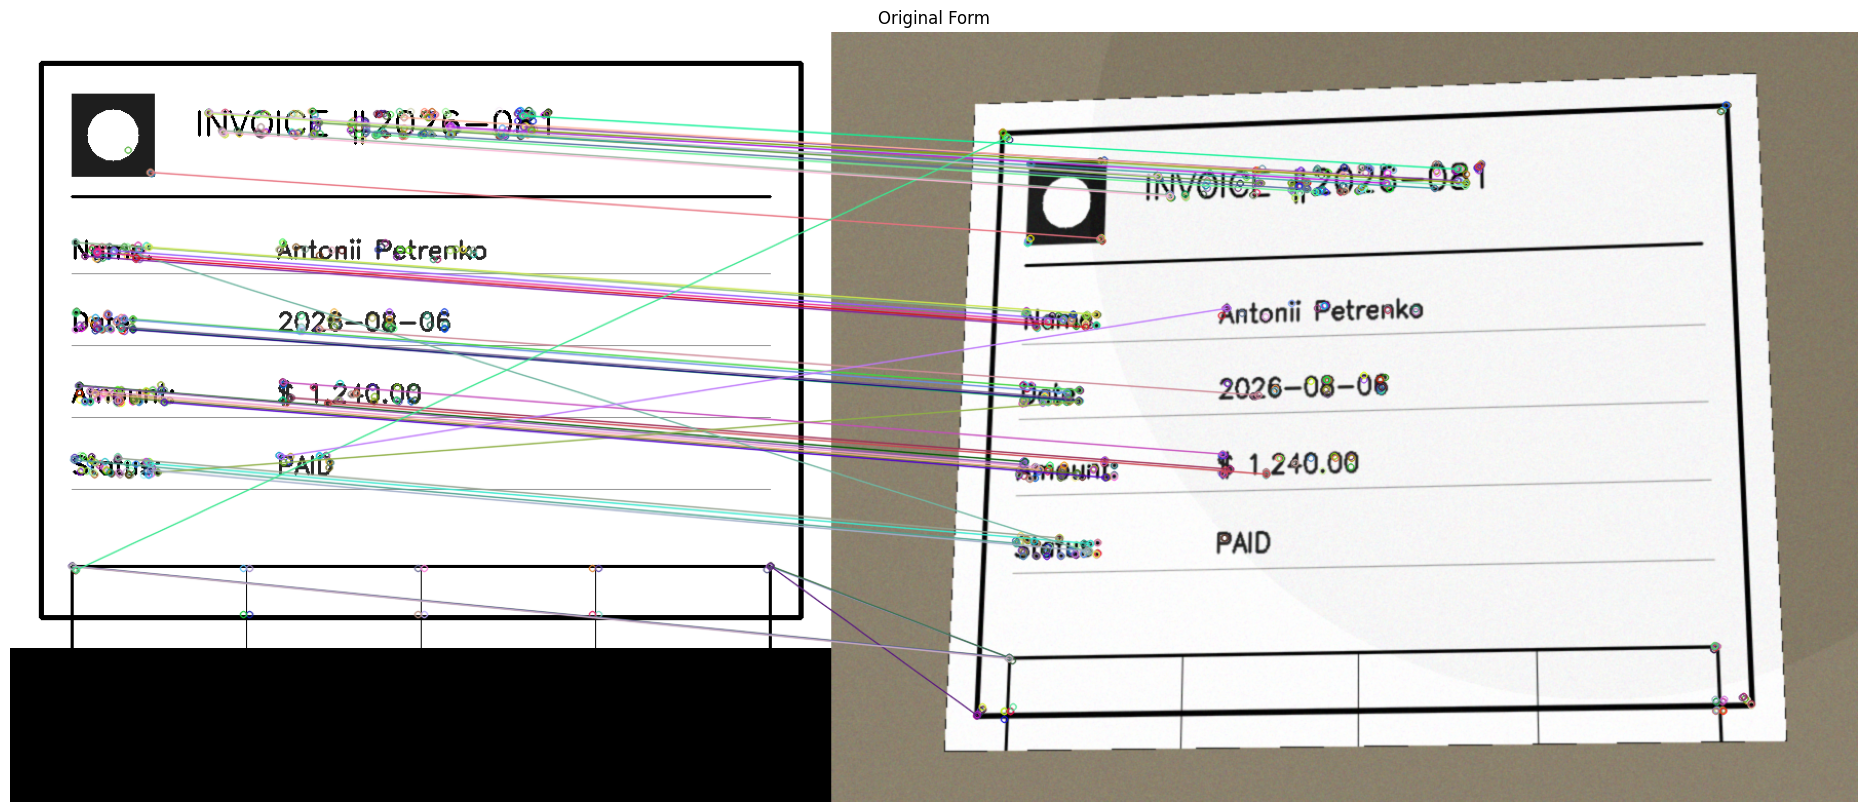

In [8]:
im_mathces = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)

plt.figure(figsize=[40,10])
plt.imshow(im_mathces); plt.axis("off"); plt.title("Original Form")

Find homogrophy 

In [9]:
points1 = np.zeros((len(matches),2),dtype = np.float32) 
points2 = np.zeros((len(matches),2),dtype = np.float32) 
for i, match in enumerate(matches):
    points1[i,:] = keypoints1[match.queryIdx].pt
    points2[i,:] = keypoints2[match.trainIdx].pt
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

Text(0.5, 1.0, 'Scanned Form')

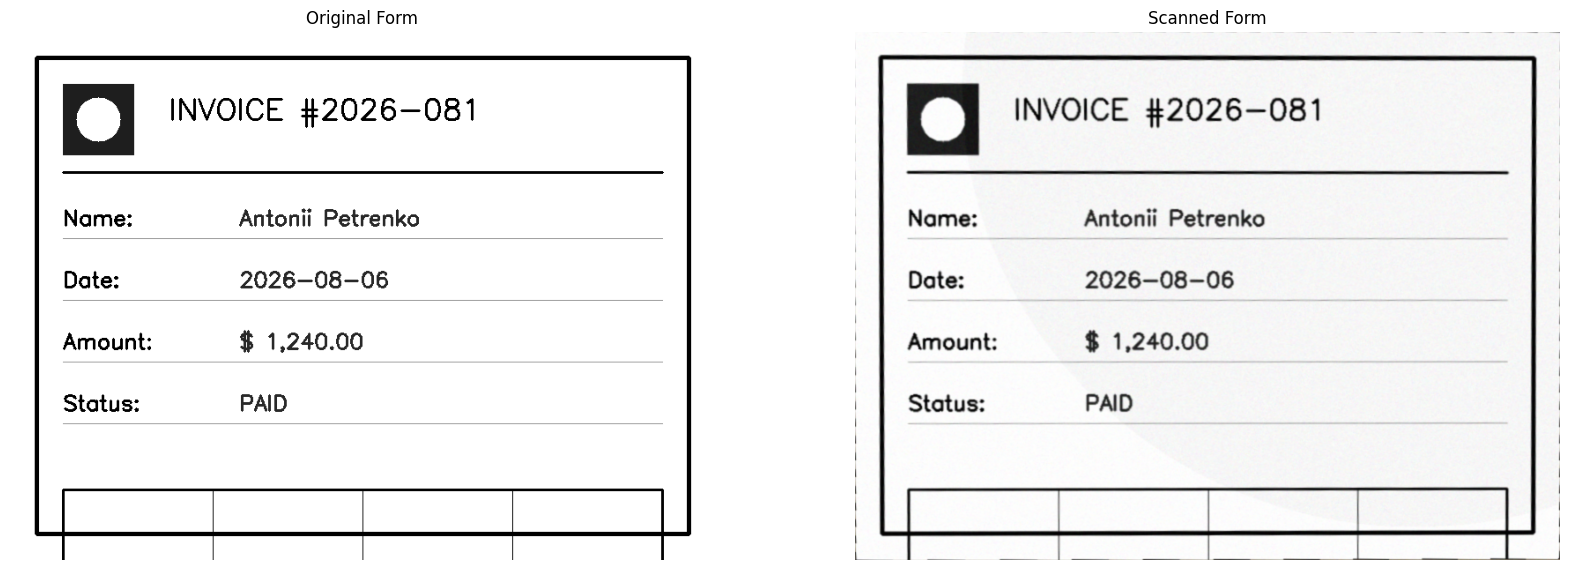

In [10]:
height, width, channel = im1.shape 
img2_reg = cv2.warpPerspective(im2, h, (width, height))

plt.figure(figsize=[20,10])
plt.subplot(121); plt.axis('off'); plt.imshow(im1); plt.title("Original Form")
plt.subplot(122); plt.axis('off'); plt.imshow(img2_reg); plt.title("Scanned Form")

In [11]:
imagefiles = glob.glob("data/panorama/*")
imagefiles.sort()

images = []
for filename in imagefiles: 
    img = cv2.imread(filename)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    images.append(img)

num_images = len(images)

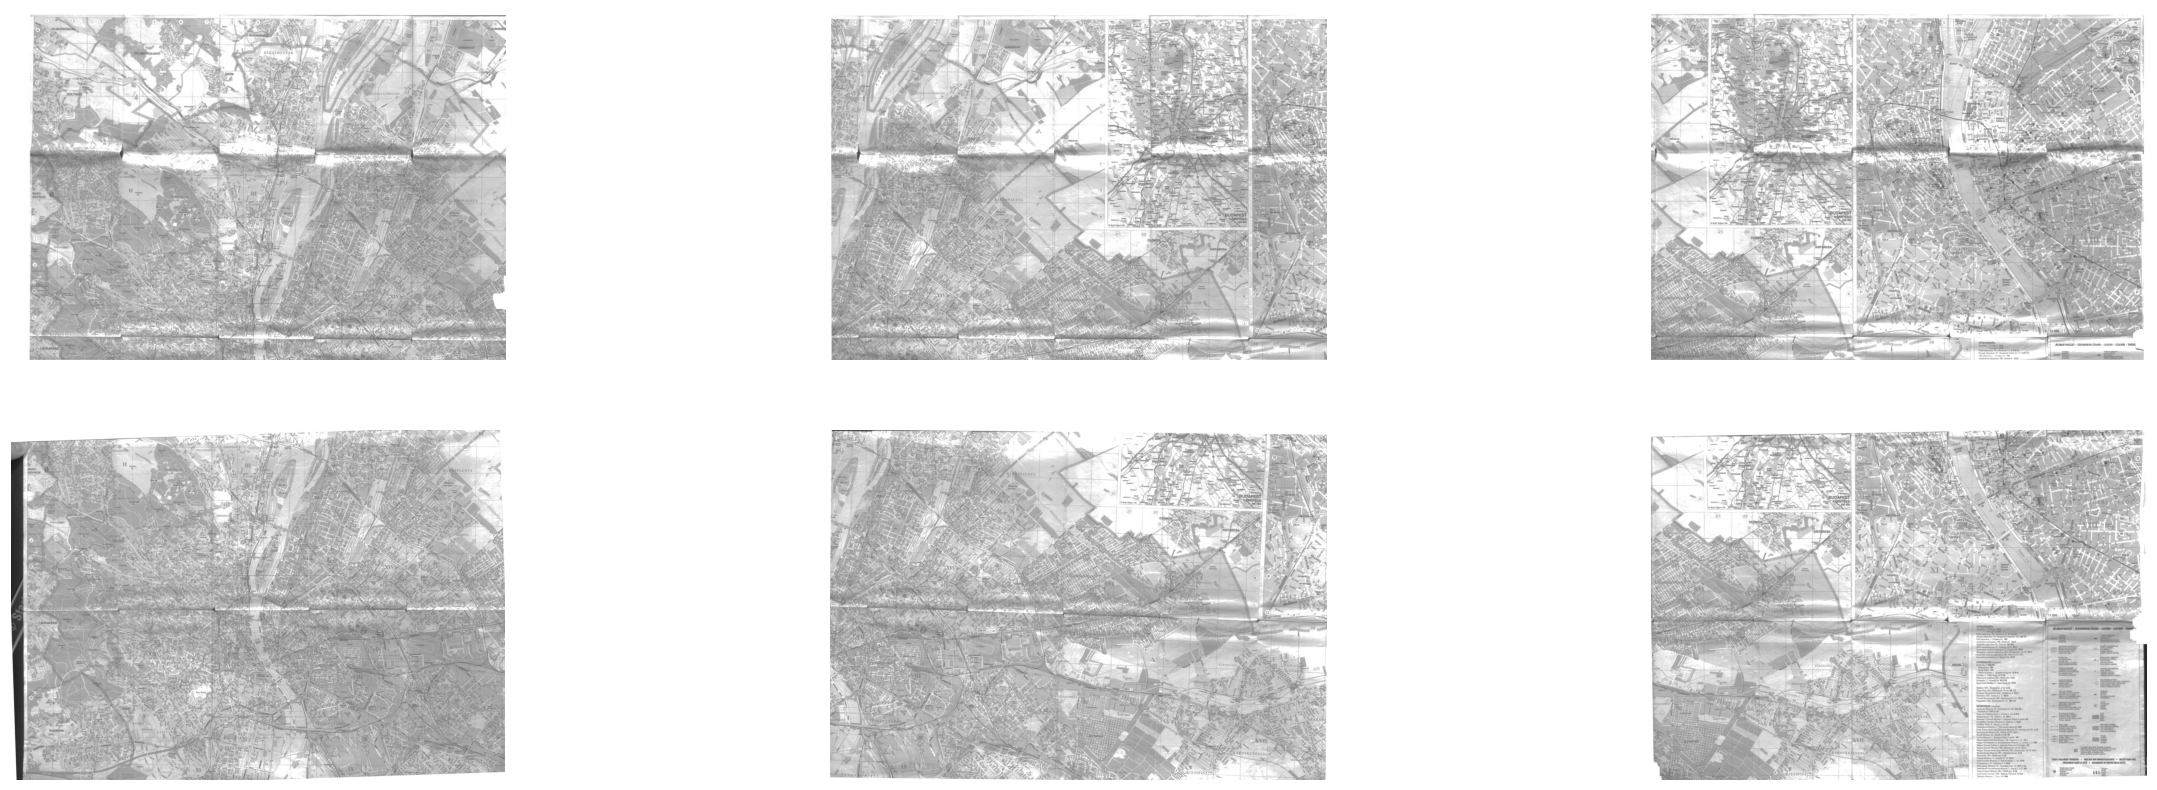

In [12]:
plt.figure(figsize=[30,10])
num_cols = 3 
num_rows = math.ceil(num_images / num_cols)
for i in range(0,num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.axis('off')
    plt.imshow(images[i])

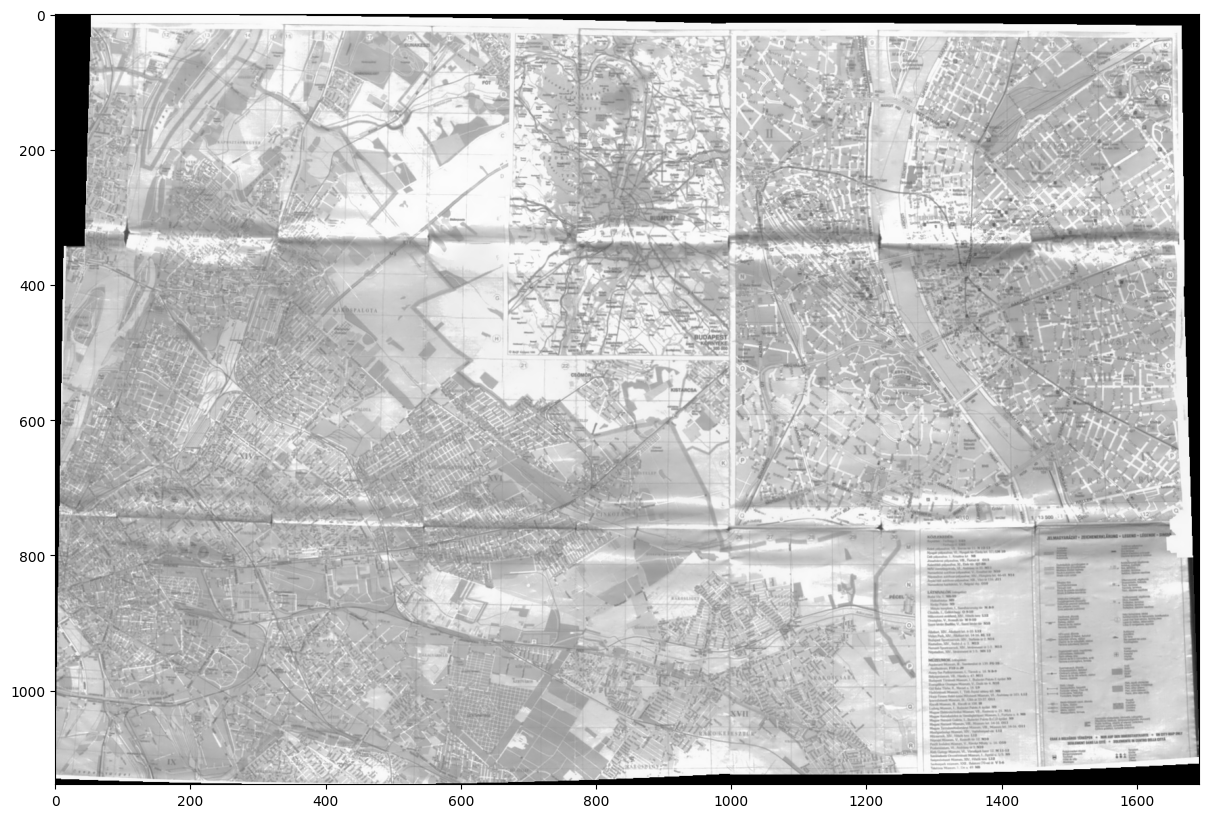

In [13]:
stitcher = cv2.Stitcher_create()
status, result = stitcher.stitch(images)
if status == 0:
    plt.figure(figsize=[30,10])
    plt.imshow(result)

Multiple Image Exposure 

In [35]:
def readImagesAndTimes():
    imagefiles = glob.glob("data/hdr/*.png")
    imagefiles.sort()

    exposure_times = np.array([
    32, 16, 8, 4, 2,
    1, 1/2, 1/4, 1/8, 1/16,
    1/32, 1/64, 1/128, 1/256, 1/512, 1/1024,
    ], dtype=np.float32)

    images = []
    for filename in imagefiles: 
        img = cv2.imread(filename)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images, exposure_times

In [36]:
images, times = readImagesAndTimes()
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)

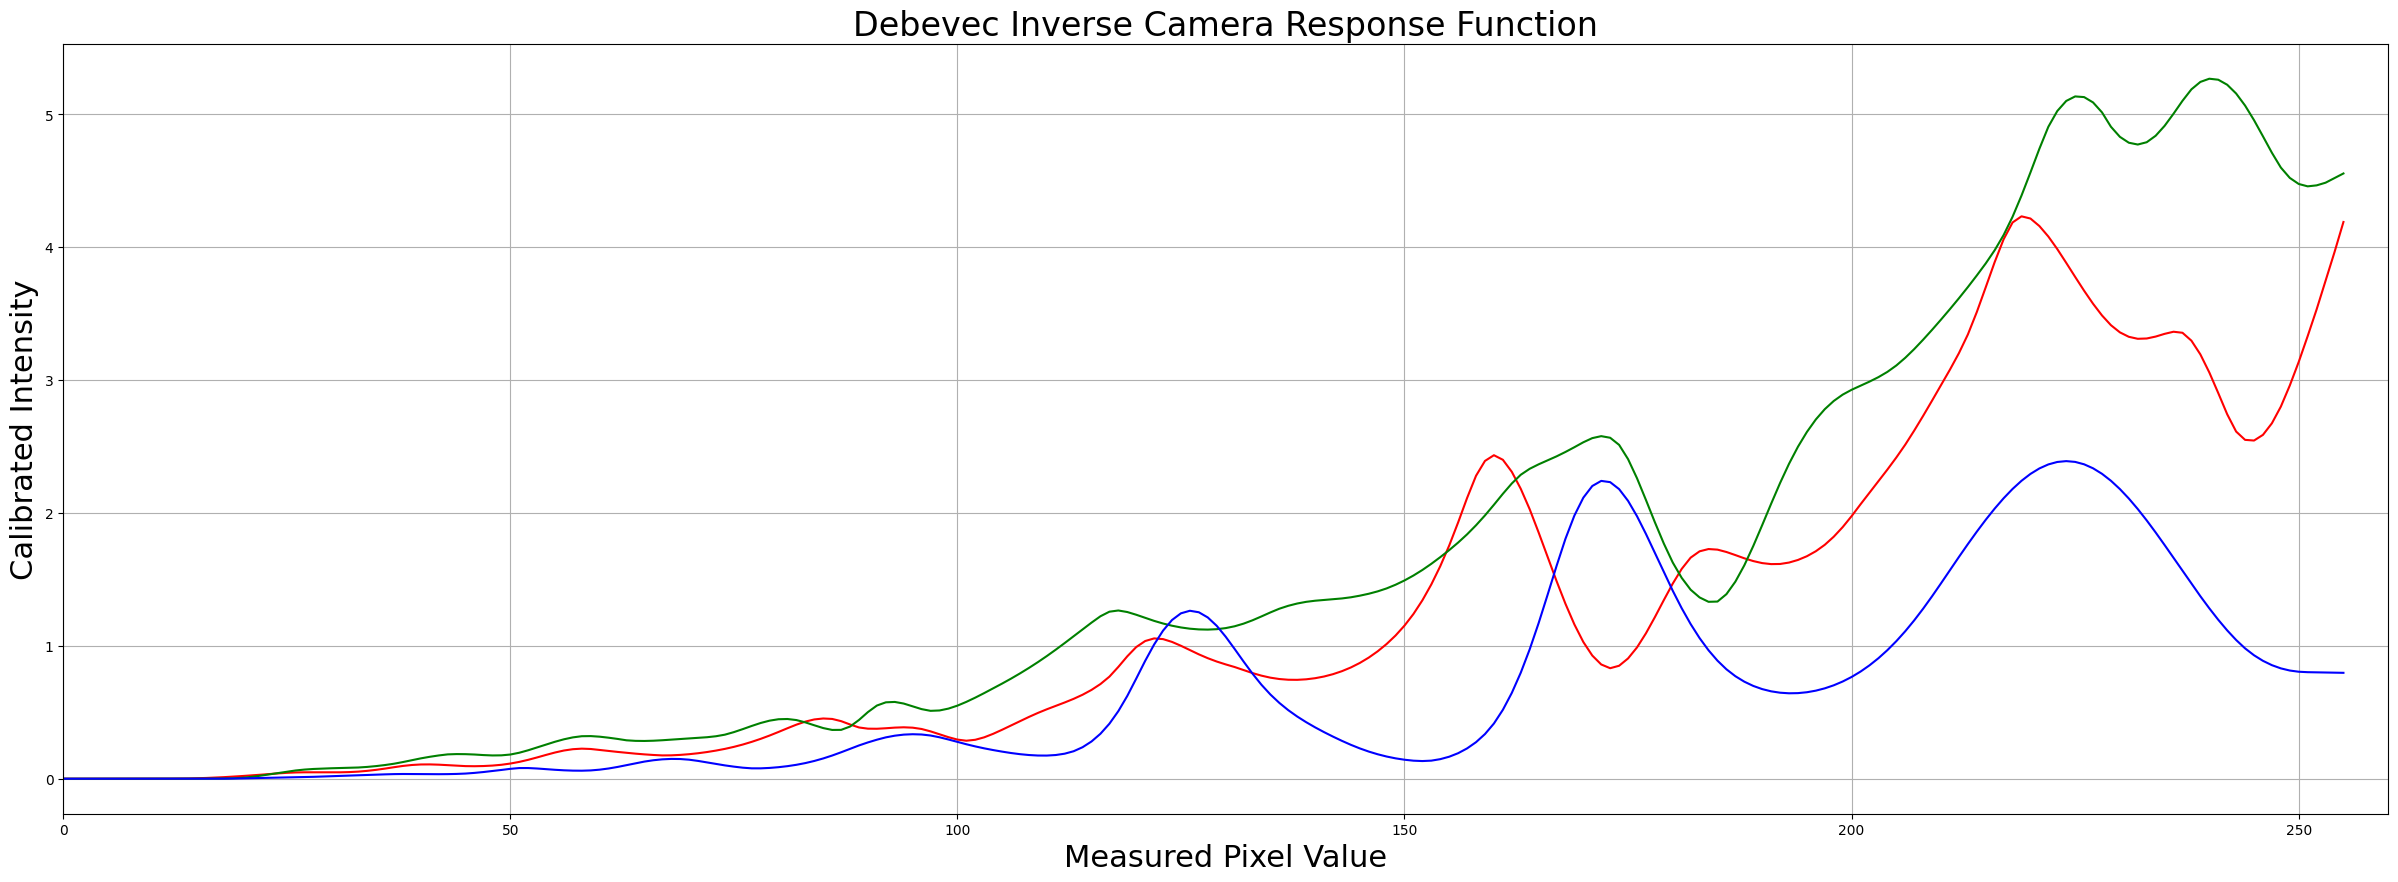

In [37]:
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=(30,10))
plt.title("Debevec Inverse Camera Response Function", fontsize = 24)
plt.xlabel("Measured Pixel Value", fontsize = 22)
plt.ylabel("Calibrated Intensity", fontsize = 22)
plt.xlim([0,260])
plt.grid()
plt.plot(x, y[:,0],'r',x,y[:,1],'g',x,y[:,2],'b');

In [38]:
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

In [39]:
tonemapDrago = cv2.createTonemapDrago(1.0,0.7)

savef ldr-Drago.jpg


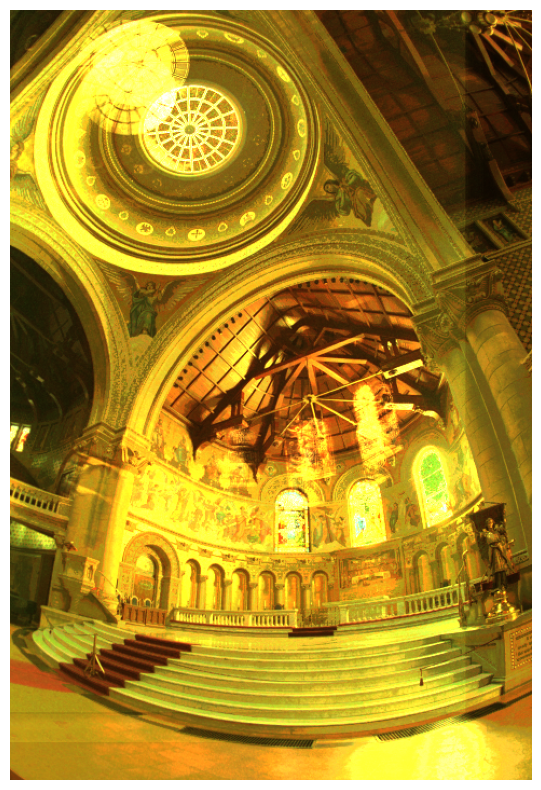

In [40]:
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3* ldrDrago 
plt.figure(figsize=(20,10)); plt.imshow(np.clip(ldrDrago,0,1)); plt.axis('off');
cv2.imwrite("outputs/ldr-Drago.jpg",ldrDrago * 255)
print("savef ldr-Drago.jpg")

saved ldr-Mantiuk.jpg


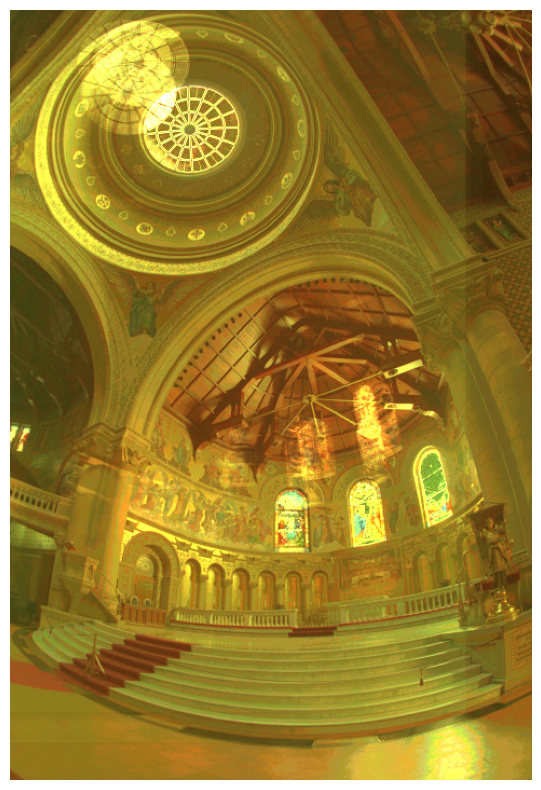

In [42]:
tonemapMantiuk = cv2.createTonemapMantiuk(2.2, 0.85, 1.2)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = 3 * ldrMantiuk
ldrMantiuk = np.clip(ldrMantiuk, 0, 1)

plt.figure(figsize=(20,10)); plt.imshow(ldrMantiuk); plt.axis("off");
cv2.imwrite("outputs/ldr-Mantiuk.jpg", cv2.cvtColor(ldrMantiuk, cv2.COLOR_RGB2BGR) * 255)
print("saved ldr-Mantiuk.jpg")